In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile
import shutil
import contextlib

# 1. Скачивание данных и EDA

In [2]:
data_train = pd.read_csv('./ml-2026-spring-price-prediction/Train.csv')
data_test = pd.read_csv('./ml-2026-spring-price-prediction/Test.csv')

In [3]:
data_train.head()

,id,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
0,0,2011-1,560,NaN,2,59,3,0,30.0,1.0,...,0,0,0,0,0,0,0,0,0,4510000
1,1,2011-1,667,NaN,10,50,2,1,25.0,NaN,...,0,0,0,0,0,0,0,0,0,13231000
2,2,2011-1,90,0.0,1,48,2,0,25.0,0.0,...,0,0,0,0,0,0,0,0,0,2008000
3,3,2011-1,94,1.0,3,62,3,1,30.0,NaN,...,0,0,0,0,0,0,0,0,0,12680000
4,4,2011-1,232,0.0,3,60,3,0,25.0,NaN,...,0,0,0,0,0,0,0,0,0,3335000


In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          100000 non-null  int64  
 1   date        100000 non-null  object 
 2   street_id   100000 non-null  int64  
 3   build_tech  70265 non-null   float64
 4   floor       100000 non-null  int64  
 5   area        100000 non-null  int64  
 6   rooms       100000 non-null  int64  
 7   balcon      100000 non-null  int64  
 8   metro_dist  95104 non-null   float64
 9   g_lift      70008 non-null   float64
 10  n_photos    100000 non-null  int64  
 11  kw1         100000 non-null  int64  
 12  kw2         100000 non-null  int64  
 13  kw3         100000 non-null  int64  
 14  kw4         100000 non-null  int64  
 15  kw5         100000 non-null  int64  
 16  kw6         100000 non-null  int64  
 17  kw7         100000 non-null  int64  
 18  kw8         100000 non-null  int64  
 19  kw9

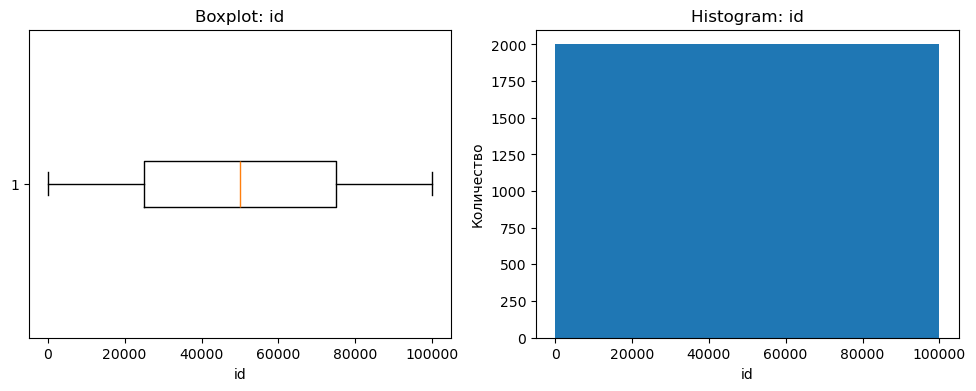

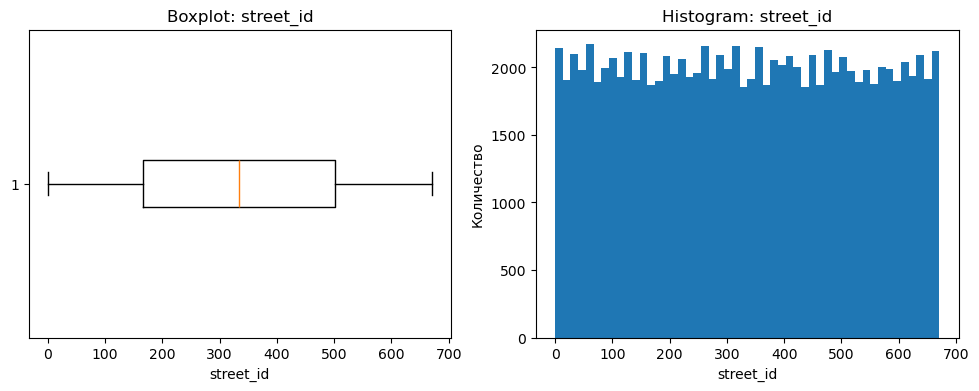

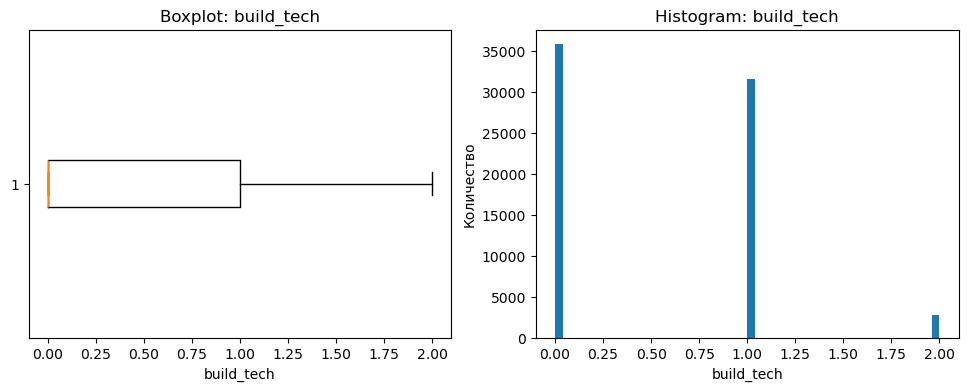

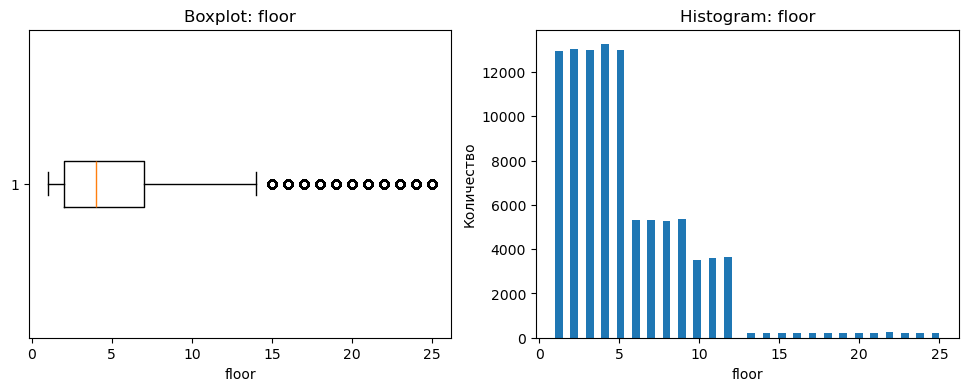

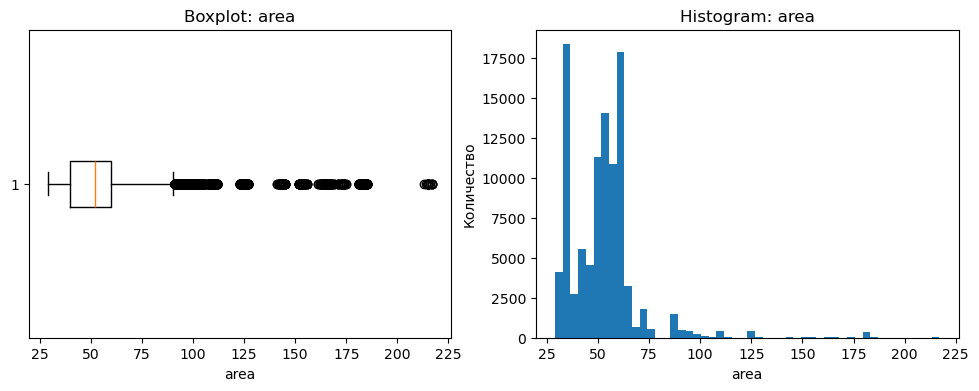

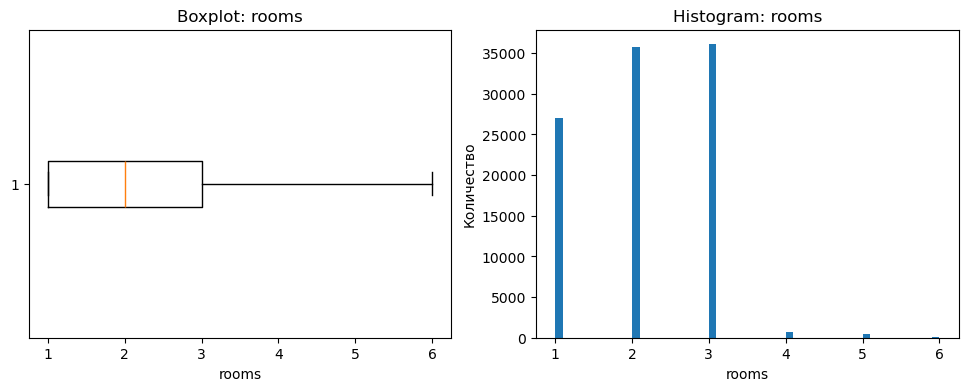

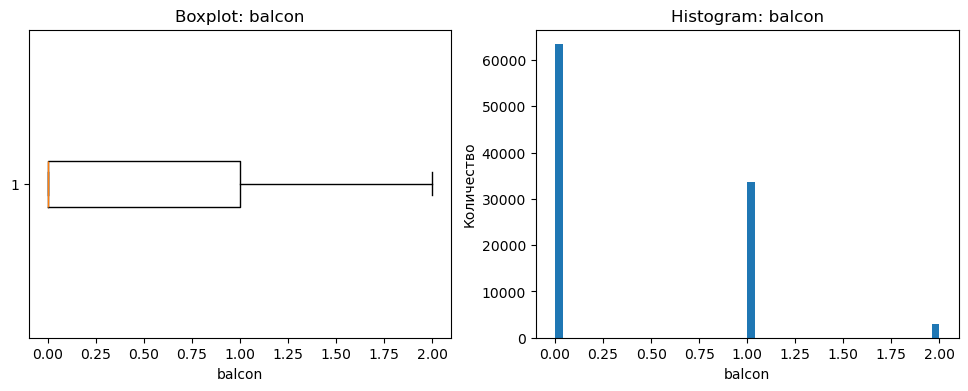

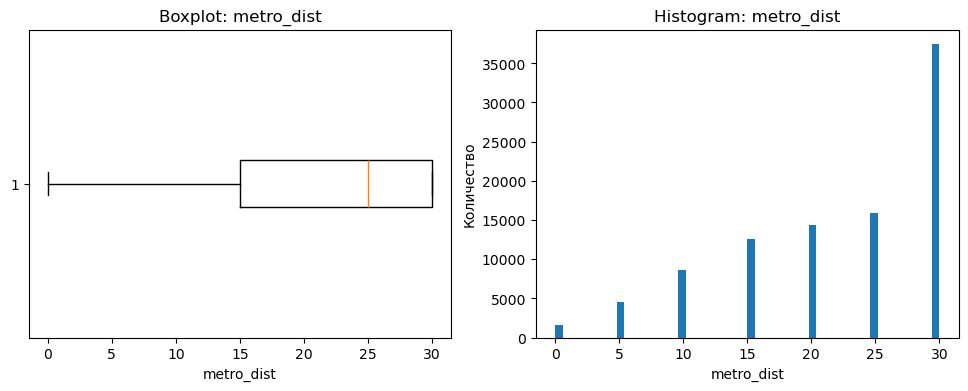

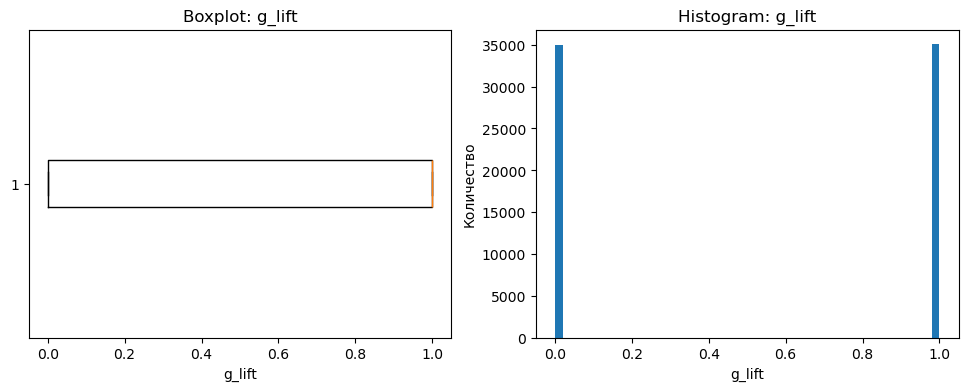

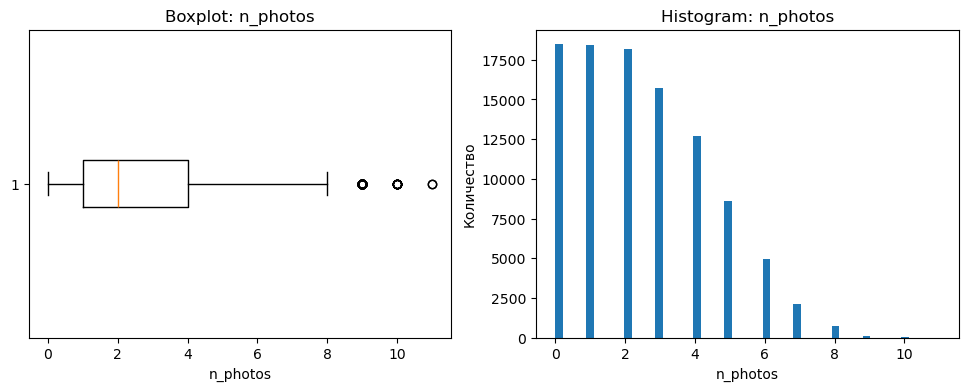

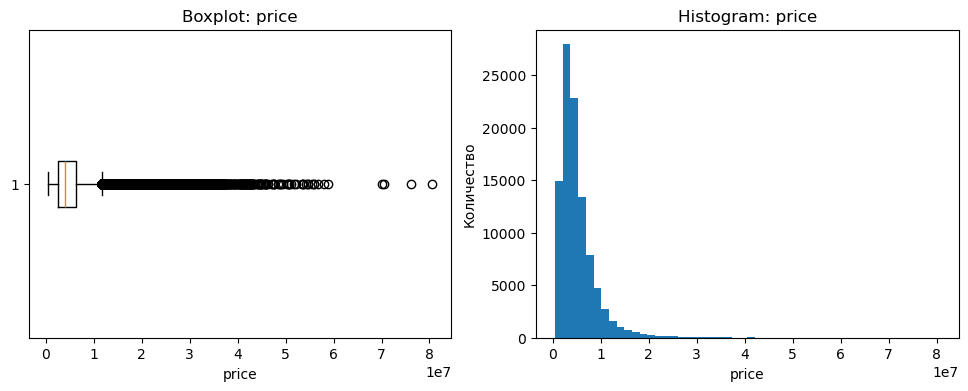

In [5]:
columns_for_visualization = [
    column for column in data_train.select_dtypes(include=['int64', 'float64']).columns
    if not column.startswith('kw')
]

for column in columns_for_visualization:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.boxplot(data_train[column].dropna(), vert=False)
    plt.title(f'Boxplot: {column}')
    plt.xlabel(column)

    plt.subplot(1, 2, 2)
    plt.hist(data_train[column].dropna(), bins=50)
    plt.title(f'Histogram: {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')

    plt.show()

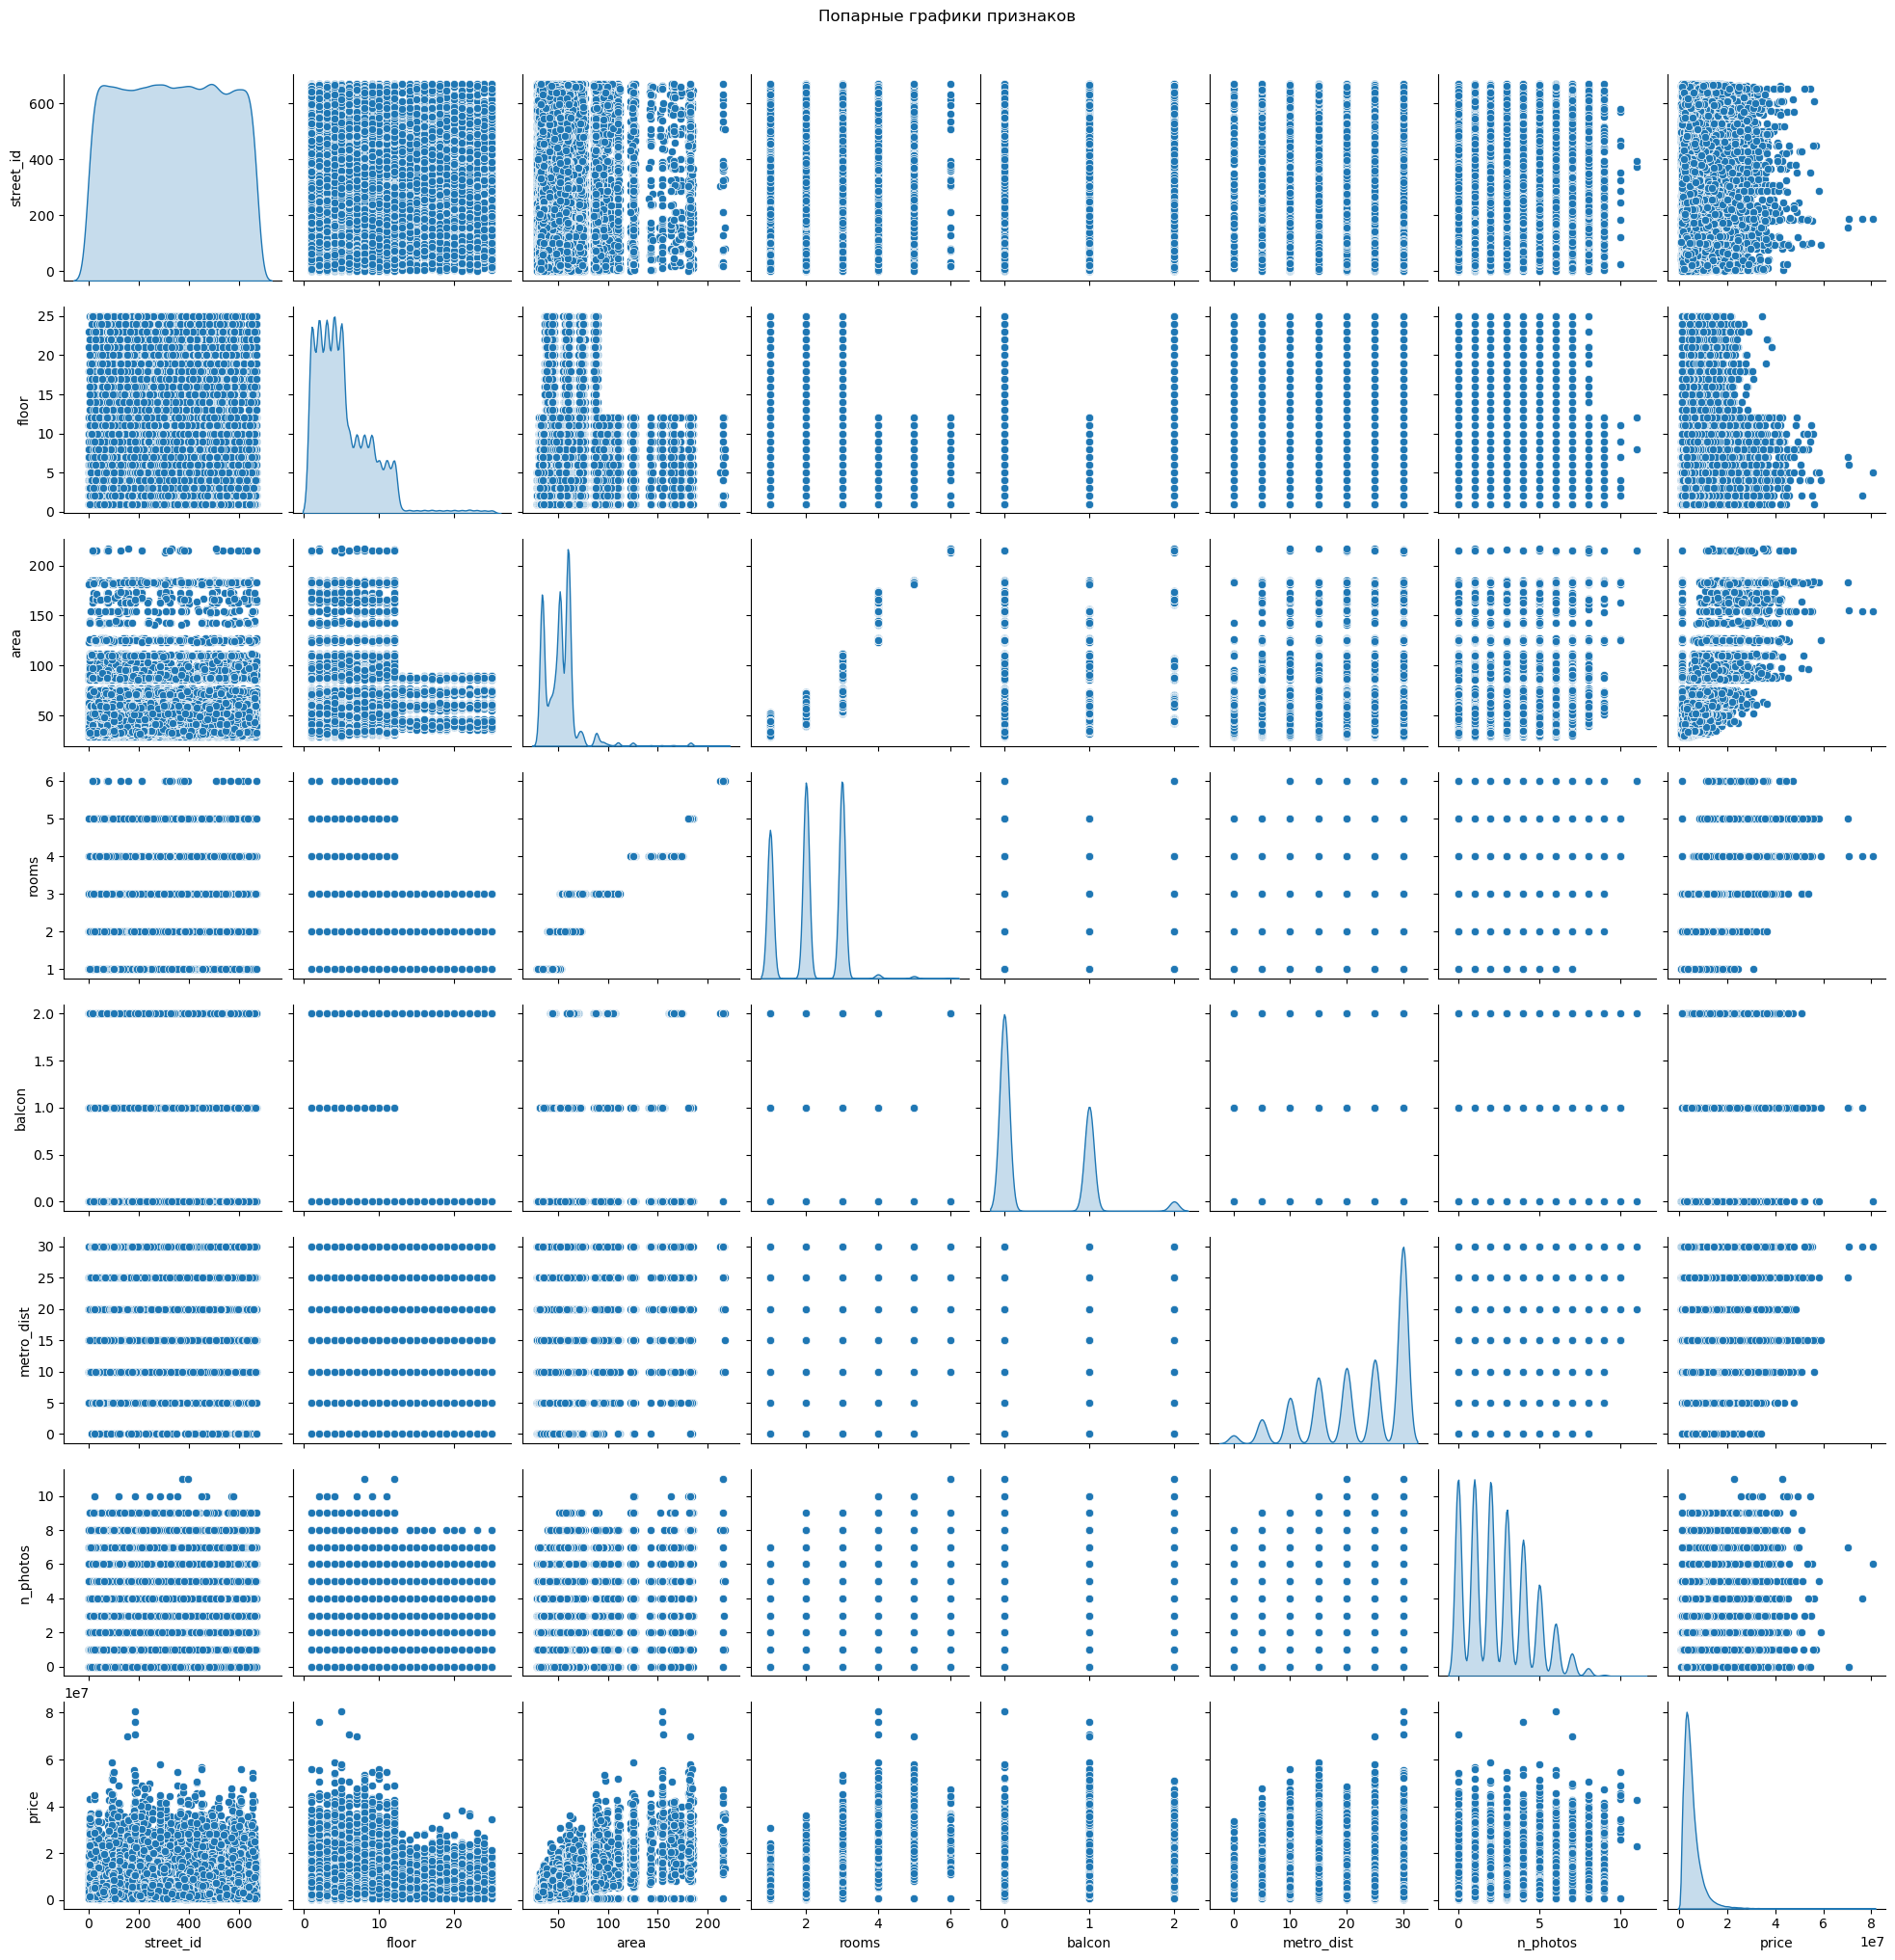

In [6]:
selected_features = [
    'street_id',
    'floor',
    'area',
    'rooms',
    'balcon',
    'metro_dist',
    'n_photos',
    'price'
]

sns.pairplot(
    data_train[selected_features].dropna(),
    diag_kind='kde'
)

plt.suptitle('Попарные графики признаков', y=1.02)
plt.show()

# 2. Обработка данных

In [7]:
data_train = data_train[
    (data_train['floor'] >= 1) & (data_train['floor'] <= 25) &
    (data_train['area'] >= 25) & (data_train['area'] <= 200) &
    (data_train['rooms'] >= 1) & (data_train['rooms'] <= 6) &
    (data_train['balcon'] >= 0) & (data_train['balcon'] <= 2) &
    (data_train['metro_dist'].isna() | ((data_train['metro_dist'] >= 0) & (data_train['metro_dist'] <= 30))) &
    (data_train['n_photos'] >= 0) & (data_train['n_photos'] <= 10) &
    (data_train['price'] > 0) & (data_train['price'] <= 50000000)
].copy()

In [8]:
def prepare_base(df, is_train=True, metro_median=None):
    df = df.copy()

    if is_train:
        y = df['price']
        X = df.drop('price', axis=1)
    else:
        y = None
        X = df.copy()

    if 'id' in X.columns:
        X = X.drop('id', axis=1)

    X['date'] = pd.to_datetime(X['date'])

    X['year'] = X['date'].dt.year
    X['month'] = X['date'].dt.month
    X['day'] = X['date'].dt.day
    X['dayofweek'] = X['date'].dt.dayofweek
    X['quarter'] = X['date'].dt.quarter

    X = X.drop('date', axis=1)

    cat_cols = ['street_id', 'build_tech', 'g_lift']

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype('object')
            X[col] = X[col].fillna('None')
            X[col] = X[col].astype(str)

    if 'metro_dist' in X.columns:
        if metro_median is None:
            metro_median = X['metro_dist'].median()
        X['metro_dist'] = X['metro_dist'].fillna(metro_median)

    if 'area' in X.columns and 'rooms' in X.columns:
        X['area_per_room'] = X['area'] / (X['rooms'] + 1)

    if 'floor' in X.columns:
        X['is_first_floor'] = (X['floor'] == 1).astype(int)
        X['is_high_floor'] = (X['floor'] >= 15).astype(int)

    if 'metro_dist' in X.columns:
        X['metro_dist_log'] = np.log1p(X['metro_dist'])

    kw_cols = [col for col in X.columns if col.startswith('kw')]

    if len(kw_cols) > 0:
        X['kw_sum'] = X[kw_cols].sum(axis=1)
        X['kw_count'] = (X[kw_cols] > 0).sum(axis=1)

    return X, y, metro_median

In [9]:
def one_hot_encode(X_train, X_valid, cat_cols):
    X_train = X_train.copy()
    X_valid = X_valid.copy()

    existing_cat_cols = [col for col in cat_cols if col in X_train.columns]

    X_train_encoded = pd.get_dummies(
        X_train,
        columns=existing_cat_cols,
        dummy_na=False
    )

    X_valid_encoded = pd.get_dummies(
        X_valid,
        columns=existing_cat_cols,
        dummy_na=False
    )

    X_train_encoded, X_valid_encoded = X_train_encoded.align(
        X_valid_encoded,
        join='left',
        axis=1,
        fill_value=0
    )

    return X_train_encoded, X_valid_encoded

In [10]:
def add_target_encoding(X_train, y_train, X_valid, cat_cols):
    X_train = X_train.copy()
    X_valid = X_valid.copy()

    global_mean = y_train.mean()
    existing_cat_cols = [col for col in cat_cols if col in X_train.columns]

    for col in existing_cat_cols:
        mapping = y_train.groupby(X_train[col]).mean()

        X_train[col + '_target_mean'] = X_train[col].map(mapping)
        X_valid[col + '_target_mean'] = X_valid[col].map(mapping)

        X_train[col + '_target_mean'] = X_train[col + '_target_mean'].fillna(global_mean)
        X_valid[col + '_target_mean'] = X_valid[col + '_target_mean'].fillna(global_mean)

    return X_train, X_valid

In [11]:
def get_mae(y_true, pred_log):
    pred = np.expm1(pred_log)
    pred = np.maximum(pred, 0)
    return mean_absolute_error(y_true, pred)

# 3. Подготовка train и holdout

In [12]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

from lightgbm import LGBMRegressor

In [13]:
X, y, metro_median = prepare_base(data_train, is_train=True)

cat_cols = ['street_id', 'build_tech', 'g_lift']
cat_cols = [col for col in cat_cols if col in X.columns]

X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.05, random_state=42)

y_train_log = np.log1p(y_train)
y_holdout_log = np.log1p(y_holdout)

/tmp/ipykernel_795157/3876472910.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna('None')


# 4. Обучение

In [14]:
lightgbm_model = LGBMRegressor(
    n_estimators=25000,
    learning_rate=0.03,
    num_leaves=100,
    max_depth=-1,
    subsample=0.95,
    colsample_bytree=0.85,
    objective='mae',
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    verbose=-1
)

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx].copy()
    X_fold_valid = X_train.iloc[valid_idx].copy()

    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    y_fold_train_log = np.log1p(y_fold_train)

    current_model = clone(lightgbm_model)

    X_fold_train_te, X_fold_valid_te = add_target_encoding(
        X_fold_train,
        y_fold_train,
        X_fold_valid,
        cat_cols
    )

    X_fold_train_encoded, X_fold_valid_encoded = one_hot_encode(
        X_fold_train_te,
        X_fold_valid_te,
        cat_cols
    )

    with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        current_model.fit(
            X_fold_train_encoded,
            y_fold_train_log
        )

    pred_log = current_model.predict(X_fold_valid_encoded)

    mae = get_mae(y_fold_valid, pred_log)
    fold_scores.append(mae)

    print(f'Fold {fold}: {mae:.2f}')

cv_mae = np.mean(fold_scores)

Fold 1: 563648.33
Fold 2: 565595.16
Fold 3: 561894.38
Fold 4: 563947.46
Fold 5: 572473.21


In [16]:
holdout_model = clone(lightgbm_model)

X_train_te, X_holdout_te = add_target_encoding(
    X_train,
    y_train,
    X_holdout,
    cat_cols
)

X_train_encoded, X_holdout_encoded = one_hot_encode(
    X_train_te,
    X_holdout_te,
    cat_cols
)

with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
    holdout_model.fit(
        X_train_encoded,
        y_train_log
    )

holdout_pred_log = holdout_model.predict(X_holdout_encoded)

holdout_pred = np.expm1(holdout_pred_log)
holdout_pred = np.maximum(holdout_pred, 0)

holdout_mae = mean_absolute_error(y_holdout, holdout_pred)

print(holdout_mae)

538617.6431558164


In [17]:
X_full, y_full, metro_median = prepare_base(data_train, is_train=True)
X_test, _, _ = prepare_base(data_test, is_train=False, metro_median=metro_median)

y_full_log = np.log1p(y_full)

test_ids = data_test['id']

final_model = clone(lightgbm_model)

/tmp/ipykernel_795157/3876472910.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna('None')
/tmp/ipykernel_795157/3876472910.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna('None')


In [18]:
X_full_te, X_test_te = add_target_encoding(
    X_full,
    y_full,
    X_test,
    cat_cols
)

X_full_encoded, X_test_encoded = one_hot_encode(
    X_full_te,
    X_test_te,
    cat_cols
)

In [19]:
with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
    final_model.fit(
        X_full_encoded,
        y_full_log
    )

# 5. Загрузка ответа

In [20]:
test_pred_log = final_model.predict(X_test_encoded)

test_pred = np.expm1(test_pred_log)
test_pred = np.maximum(test_pred, 0)

submission = pd.DataFrame({
    'id': test_ids,
    'price': test_pred
})

submission.to_csv('answer.csv', index=False)

In [21]:
submission.head()

,id,price
0,100000,8.605987e+06
1,100001,4.893000e+06
2,100002,3.943885e+06
3,100003,3.165599e+06
4,100004,6.794040e+06
